# SMS Spam Detection with ML & NLP (SVM vs RandomForest)

<div align='center'>
<img src='https://camo.githubusercontent.com/00c597e53198f684d7d78223c6ba7e9093ffae49b350987f24ff57bd8f2919af/68747470733a2f2f656469746f722e616e616c79746963737669646879612e636f6d2f75706c6f6164732f333230383668656164696e672e6a706567' width='500'>
</div>

## Introduction

Spam message detection is a fundamental problem in Natural Language Processing (NLP) with real-world applications in email filtering and communication security. In this notebook, we analyze and build machine learning models to classify SMS messages as spam or ham using text processing techniques.

The dataset consists of 5,572 labeled messages with two features: message text and class labels. We apply text cleaning, feature extraction, and multiple machine learning algorithms to evaluate performance and identify the most effective model.

Key steps include:
- Text preprocessing using NeatText
- Feature extraction with CountVectorizer (n-grams)
- Model training using Random Forest and Support Vector Machine (SVM)
- Sentiment analysis using TextBlob
- Exploration of Named Entity Recognition (NER)

Our goal is to build a robust and accurate spam detection pipeline.

## Imported Libraries

In [12]:
!pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 3.0 MB/s eta 0:00:0000:01


In [13]:
import pandas as pd
import neattext as nfx

## Read Data

In [14]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
    encoding='latin-1')

## EDA

In [15]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [16]:
df=df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1 )

In [17]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.columns=['class','text']

In [19]:
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [21]:
df.shape

(5572, 2)

In [22]:
df['class'].value_counts()

class
ham     4825
spam     747
Name: count, dtype: int64

## Text Cleaning and Preprocessing with NeatText

In [23]:
# normalize
df['text']=df['text'].apply(nfx.normalize)

In [24]:
# clean_text
df['text']=df['text'].apply(nfx.clean_text)

In [25]:
# remove_special_characters
df['text']=df['text'].apply(nfx.remove_special_characters)

In [26]:
df['text'][0]

'jurong point crazy available bugis n great world la e buffet cine got amore wat'

## Join

In [27]:
s=''.join(df['text'])

In [28]:
s=nfx.clean_text(s)

In [29]:
s=nfx.remove_special_characters(s)

In [30]:
s=nfx.TextFrame(s)

In [31]:
s.describe()

Key      Value          
Length  : 250543         
vowels  : 75977          
consonants: 136055         
stopwords: 0              
punctuations: 0              
special_char: 0              
tokens(whitespace): 38512          
tokens(words): 38512          


In [32]:
s.length

250543

In [33]:
s.head()

'juron'

In [34]:
s.tail()

' true'

In [35]:
s.readability()

{'automated readability': 19265.211294401746, 'description': None}

In [36]:
import seaborn as sns

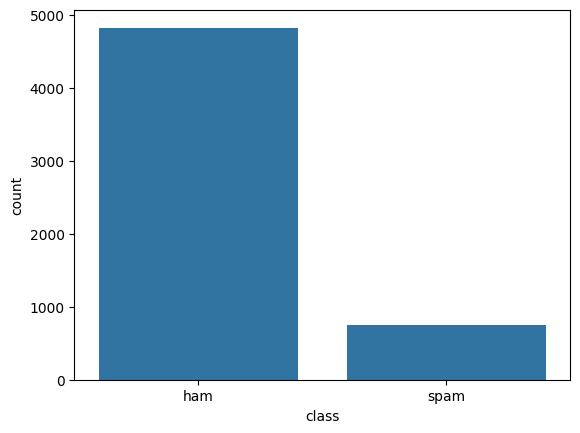

In [37]:
sns.countplot(x=df['class']); # imbalanced data

In [38]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [39]:
x=df['text']
y=df['class']

## Vectorization / Model Pipeline

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
from sklearn.pipeline import Pipeline

In [43]:
clf=Pipeline([('CountVect',CountVectorizer(ngram_range=(1,2))),('Classifier', RandomForestClassifier())])

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20)

In [46]:
clf.fit(x_train,y_train)

Pipeline(steps=[('CountVect', CountVectorizer(ngram_range=(1, 2))),
                ('Classifier', RandomForestClassifier())])

In [47]:
tahmin=clf.predict(x_test)

In [48]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [49]:
accuracy_score(y_test,tahmin)

0.9668161434977578

In [50]:
confusion_matrix(tahmin,y_test)

array([[965,  37],
       [  0, 113]])

In [52]:
print(classification_report(y_test,tahmin))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## Support Vector Machine

In [53]:
from sklearn.svm import SVC

In [54]:
svm=Pipeline([('CountVect',CountVectorizer(ngram_range=(1,2))),('Classifier', SVC())])

In [55]:
svm.fit(x_train,y_train)

Pipeline(steps=[('CountVect', CountVectorizer(ngram_range=(1, 2))),
                ('Classifier', SVC())])

In [56]:
tahmin2=svm.predict(x_test)

In [57]:
accuracy_score(y_test,tahmin)

0.9668161434977578

In [58]:
print(classification_report(y_test,tahmin2))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       0.99      0.81      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



## Testing the Model

In [59]:
df.sample(10)

,class,text
160,ham,safe need miss envy sees real life
3128,ham,haha better late ever way swing by
5399,ham,hes apparently bffs carly quick
4488,ham,new deus ex game comin early yr
3520,ham,hey going quit soon xuhui working till end month
2037,ham,oh sorry
4272,ham,kind of missed train cos asthma attack nxt hal...
5301,ham,time come tomorrow
753,ham,library
2489,ham,docs appointments week im tired shoving stuff ...


In [60]:
df['text'][4]

'nah think goes usf lives'

In [61]:
clf.predict([df['text'][4]])

array(['ham'], dtype=object)

In [62]:
svm.predict([df['text'][4]])

array(['ham'], dtype=object)

In [63]:
df['text'][504]

' congratulations  weeks competition draw u  prize claim  tcsstop sms '

In [64]:
clf.predict([df['text'][504]])

array(['spam'], dtype=object)

In [65]:
svm.predict([df['text'][504]])

array(['spam'], dtype=object)

## Save Model

In [66]:
import joblib
joblib.dump(svm,'svm_hs.pkl')
joblib.dump(svm,'clf_hs.pkl')

['clf_hs.pkl']

## Load Model

In [67]:
loaded_model=joblib.load('svm_hs.pkl') 

In [68]:
loaded_model.predict([df['text'][4]])

array(['ham'], dtype=object)

## WordCloud

In [69]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [70]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [71]:
def wc(data,color):
    plt.figure(figsize=(10,10))
    wc=WordCloud(background_color=color, stopwords=STOPWORDS)
    wc.generate(''.join(data))
    plt.imshow(wc)
    plt.axis('off')

In [72]:
spam=df[df['class']=='spam']
ham=df[df['class']=='ham']

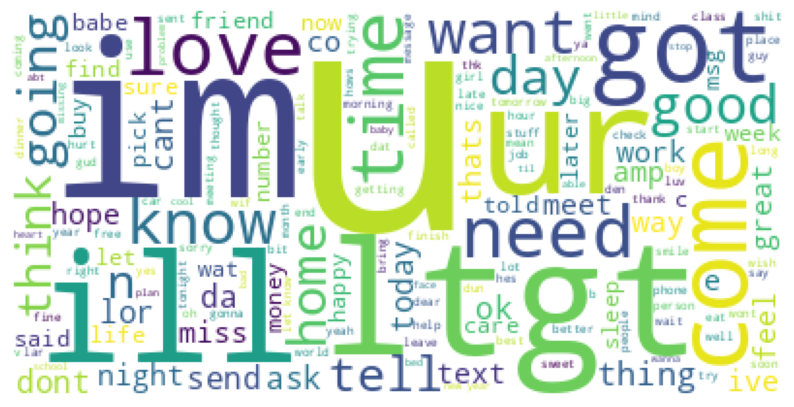

In [73]:
wc(ham['text'],'white')

In [74]:
def wc(data,color):
    plt.figure(figsize=(10,10))
    mask=np.array(Image.open('/kaggle/input/datasets/emirkaanozdemr/cloud-picture/cloud.png'))
    wc=WordCloud(background_color=color, stopwords=STOPWORDS,mask=mask)
    wc.generate(''.join(data))
    plt.imshow(wc)
    plt.axis('off')

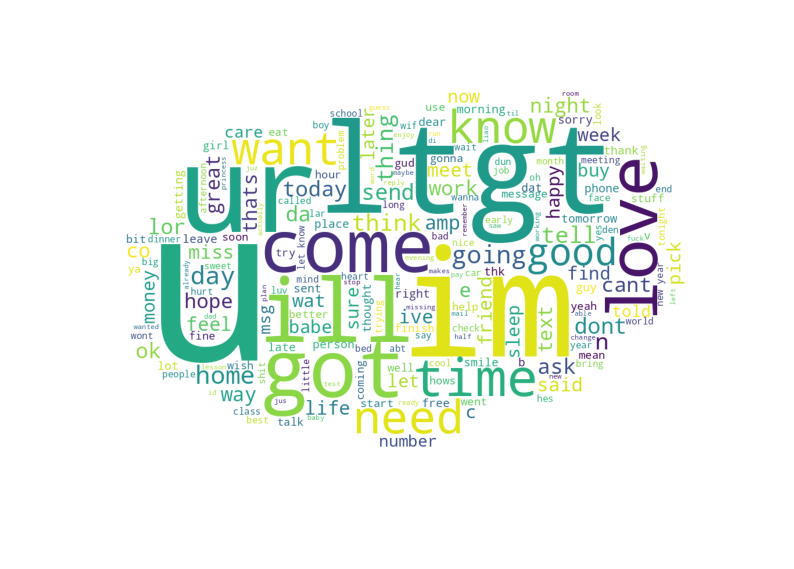

In [75]:
wc(ham['text'],'white')

## Sentiment Analysis

In [76]:
from textblob import TextBlob

In [90]:
df['text'][1060]

'im working technical support voice processnetworking field'

In [91]:
blob = TextBlob(df['text'][1060])

In [92]:
blob.sentiment.polarity

0.0

In [80]:
df['text'][12]

'urgent week free membership  prize jackpot txt word claim no tc wwwdbuknet lccltd pobox'

In [81]:
blob = TextBlob(df['text'][12])

In [82]:
blob.sentiment.polarity

0.4

In [86]:
df['text'][5007]

'fool dont cheat ok'

In [87]:
blob = TextBlob(df['text'][5007])

In [88]:
blob.sentiment.polarity

0.5

## NER (Named Entity Recognition)

In [93]:
import spacy

In [94]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 44.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [95]:
nlp=spacy.load(name='en_core_web_md')

In [96]:
sample_text = df['text'].iloc[0] 

In [97]:
doc = nlp(sample_text)

In [98]:
for token in doc:
    print(token.text, token.lemma_, token.pos_, token.tag_, token.dep_,
          token.shape_, token.is_alpha, token.is_stop)

jurong jurong PROPN NNP compound xxxx True False
point point PROPN NNP npadvmod xxxx True False
crazy crazy PROPN NNP amod xxxx True False
available available ADJ JJ amod xxxx True False
bugis bugis PROPN NNP nmod xxxx True False
n n CCONJ CC cc x True False
great great ADJ JJ amod xxxx True False
world world NOUN NN nmod xxxx True False
la la PROPN NNP compound xx True False
e e PROPN NNP compound x True False
buffet buffet NOUN NN compound xxxx True False
cine cine NOUN NN nsubj xxxx True False
got get VERB VBD ROOT xxx True False
amore amore NOUN NN compound xxxx True False
wat wat PROPN NNP dobj xxx True False


In [99]:
from spacy import displacy

In [100]:
displacy.render(doc, style="dep")

In [101]:
for ent in doc.ents:
    print(ent.text, ent.label_)

jurong point PERSON


In [102]:
all_entities = []

for text in df['text'].head(100):  # sample 100
    doc = nlp(text)
    for ent in doc.ents:
        all_entities.append((ent.text, ent.label_))

entities_df = pd.DataFrame(all_entities, columns=['Entity', 'Type'])
entities_df.head()

,Entity,Type
0,jurong point,PERSON
1,wif u oni,PERSON
2,fa,ORG
3,u dun early hor,PERSON
4,usf,ORG


In [103]:
for text in df['text'].head(50):  
    doc = nlp(text)
    displacy.render(doc, style="ent")

/usr/local/lib/python3.12/dist-packages/spacy/displacy/__init__.py:215: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


##  Conclusion

In this project, we successfully built a high-performing spam detection system using NLP and machine learning techniques.

Both Random Forest and Support Vector Machine (SVM) models achieved strong performance with an accuracy of **96.68%**, demonstrating the effectiveness of n-gram based feature extraction.

Key takeaways:
- Text preprocessing significantly improves model performance
- N-gram features (1,2) capture contextual information effectively
- SVM and Random Forest perform similarly well on this dataset
- Sentiment analysis provides additional insights but is not critical for classification

Overall, this project highlights how combining NLP techniques with machine learning models can effectively solve real-world classification problems.